In [1]:
import os, io, ssl, json, re, sqlite3, zipfile, urllib.request, textwrap, operator
from typing import Annotated, Literal
from typing_extensions import TypedDict
import pandas as pd
from dotenv import load_dotenv

import truststore
truststore.inject_into_ssl()

# Prints the wall-clock time under every cell.
%load_ext autotime


def pretty_print(*args, width=95):
    """Reflow long prose to `width`, but leave tables / SQL output untouched."""
    text = " ".join(str(a) for a in args)
    if "\n" in text.strip("\n") or re.search(r"\S  +\S", text):
        print(text)
    else:
        print(textwrap.fill(text.strip(), width=width))


load_dotenv("/Users/shivam13juna/Documents/scaler/GEN_AI_REF/openai_key.env")
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY not found — check the openai_key.env path."

WORKER_MODEL = "gpt-4.1-nano"      # the cheap workhorse used for every agent below
REVIEWER_MODEL = "gpt-4.1-mini"    # the independent judge in P6
pretty_print(f"API key loaded.  worker={WORKER_MODEL}  reviewer={REVIEWER_MODEL}")

API key loaded.  worker=gpt-4.1-nano  reviewer=gpt-4.1-mini
time: 972 µs (started: 2026-09-12 21:10:08 +05:30)


In [3]:
DB_PATH = "online_retail.db"

# The three tools, as ordinary Python. Every framework in this notebook wraps THESE.
def list_tables():
    """Return the names of every table in the database."""
    connection = sqlite3.connect(DB_PATH)
    names = [row[0] for row in connection.execute(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")]
    connection.close()
    return ", ".join(names)


def get_schema(table):
    """Return one table's columns (name + type)."""
    connection = sqlite3.connect(DB_PATH)
    columns = connection.execute(f"PRAGMA table_info({table})").fetchall()
    connection.close()
    if not columns:
        return f"No such table: {table}"
    return f"Table '{table}': " + ", ".join(f"{col[1]} ({col[2]})" for col in columns)


def run_sql(query, max_rows=20):
    """Run a read-only query and return rows as text — or the error message as text."""
    # mode=ro opens the file READ-ONLY: SQLite itself refuses any write, whoever asked for it.
    # This is the one tool that runs SQL the model wrote, so it is the one that needs the lock.
    connection = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
    try:
        cursor = connection.execute(query)
        if cursor.description is None:
            return "OK (no rows returned)."
        column_names = [description[0] for description in cursor.description]
        rows = cursor.fetchmany(max_rows)
        body = "\n".join(" | ".join(str(value) for value in row) for row in rows) or "(0 rows)"
        return f"{' | '.join(column_names)}\n{body}"
    except Exception as error:
        # Errors come back as TEXT, not exceptions, so an agent can read and recover from them.
        return f"SQL ERROR: {type(error).__name__}: {error}"
    finally:
        connection.close()


print(list_tables())
print(get_schema("invoices"))
print(run_sql("SELECT COUNT(*) AS cancelled FROM invoices WHERE is_cancelled = 1"))

invoices, line_items, products
Table 'invoices': invoice_no (TEXT), customer_id (REAL), invoice_ts (TEXT), country (TEXT), is_cancelled (INTEGER)
cancelled
3836
time: 2.91 ms (started: 2026-09-12 21:11:05 +05:30)


# LangChain

In [ ]:
#{"role": "system", "content": f"You are a helpful assistant that answers questions about the database at {DB_PATH}.  You have access to three tools: list_tables(), get_schema(table), and run_sql(query).  You can only use these tools to answer questions.  You cannot access the database directly.",
#"role": "user", "content": "What tables are in the database?"
#"role": "assistant", "content": list_tables()}

In [ ]:
from openai import OpenAI

client = OpenAI()

conversation = [
    {
        "role": "system",
        "content": "You are a terse data analyst.",
    },
    {
        "role": "user",
        "content": "Name the three tables in a retail schema, in one line.",
    },
]

response = client.responses.create(
    model=WORKER_MODEL,
    input=conversation,
    temperature=0,
)

pretty_print("reply:", response.output_text)

print("\nreply type:", type(response).__name__)

In [30]:
from langchain.chat_models import init_chat_model
from langchain.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage

# "openai:gpt-4.1-nano" — the provider prefix is the whole abstraction. Point this at
# "anthropic:claude-..." and nothing else in the notebook needs to change.
language_model = init_chat_model(f"openai:{WORKER_MODEL}", temperature=0)

# Messages are typed objects rather than {"role": ..., "content": ...} dictionaries.
conversation = [
    SystemMessage("You are a terse data analyst."),
    HumanMessage("Name the three tables in a retail schema, in one line."),
]
model_reply = language_model.invoke(conversation)
pretty_print("reply:", model_reply.content)
print("\nreply type:", type(model_reply).__name__)

reply: Customers, Orders, Products

reply type: AIMessage
time: 1.36 s (started: 2026-09-12 22:21:53 +05:30)


In [32]:
language_model.invoke("long weekend is going on!!! and we're in class!! :()")

AIMessage(content="I know, right? Long weekends are the best, and being stuck in class can be a real bummer. Hang in there—just a little more to go! Maybe you can plan something fun for after class to make the most of your time off. You've got this! 😊", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 20, 'total_tokens': 77, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_a806186e36', 'id': 'chatcmpl-ENLFf6ApIFOGuP86Jc4DEVrv2NN28', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a09688-cba0-7e31-8393-05068e8dd3b6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 20, 'output_tokens': 57, 'total_tokens': 77, 'input_

time: 1.16 s (started: 2026-09-12 22:22:22 +05:30)


In [5]:
from langchain.tools import tool


# Each wrapper delegates to the plain function from P0 — no logic is duplicated.
@tool
def sql_list_tables() -> str:
    """List all tables in the retail database."""
    return list_tables()


@tool
def sql_get_schema(table: str) -> str:
    """Show the columns and their types for one table."""
    return get_schema(table)


@tool
def sql_run(query: str) -> str:
    """Run a read-only SQLite query and return the rows, or a 'SQL ERROR: ...' string."""
    return run_sql(query)


DATABASE_TOOLS = [sql_list_tables, sql_get_schema, sql_run]

# This is the generated schema — exactly what we hand-wrote as JSON before.
print("tool name       :", sql_run.name)
print("description     :", sql_run.description)
print("generated schema:", sql_run.args_schema.model_json_schema()["properties"])

tool name       : sql_run
description     : Run a read-only SQLite query and return the rows, or a 'SQL ERROR: ...' string.
generated schema: {'query': {'title': 'Query', 'type': 'string'}}
time: 43.7 ms (started: 2026-09-12 21:18:00 +05:30)


In [6]:
# Binding attaches the schemas to the model. The model still cannot RUN anything —
# it can only reply with a request, exactly as in the raw OpenAI protocol.
model_with_tools = language_model.bind_tools(DATABASE_TOOLS)
tool_request = model_with_tools.invoke("How many invoices are cancelled?")

print("content    :", repr(tool_request.content))       # usually empty — it wants a tool first
print("tool_calls :", tool_request.tool_calls)

content    : ''
tool_calls : [{'name': 'sql_list_tables', 'args': {}, 'id': 'call_0qXjg3HFF4RRp8QL6nmRjGBJ', 'type': 'tool_call'}]
time: 1.4 s (started: 2026-09-12 21:19:34 +05:30)


In [8]:
from langchain.agents import create_agent
from IPython.display import Image, display

# The question this notebook asks of every agent it builds.
BUSINESS_QUESTION = "What was our total revenue, excluding cancelled orders?"

# One instruction string, shared by all three frameworks, so the comparison in P9 is fair.
# The tool ORDER is spelled out deliberately: left to itself the model will guess a plausible
# table name, query it, and report that the data is missing. Naming the discovery steps costs
# one sentence and removes that whole failure mode.
AGENT_INSTRUCTIONS = (
    "You are InsightAgent, a data analyst for an online-retail store. "
    "Always work in this order: first list the tables, then inspect the schema of every table "
    "you intend to use, and only then write SQL. Never guess a table or column name. "
    "Revenue must EXCLUDE cancelled invoices (invoices.is_cancelled = 1). "
    "State the final answer clearly, including the number."
)

prebuilt_agent = create_agent(
    model=f"openai:{REVIEWER_MODEL}",
    tools=DATABASE_TOOLS,
    system_prompt=AGENT_INSTRUCTIONS,
)


# The input and output are both a message list under the key "messages".
agent_result = prebuilt_agent.invoke({"messages": [HumanMessage(BUSINESS_QUESTION)]})
pretty_print("ANSWER:", agent_result["messages"][-1].content)

ANSWER: The total revenue, excluding cancelled orders, is 10,644,560.42.
time: 5.15 s (started: 2026-09-12 21:21:32 +05:30)


In [9]:
# Every intermediate step is in the returned message list — nothing is hidden.
# This is the same trace we printed by hand from a manual loop.
for message in agent_result["messages"]:
    label = type(message).__name__
    if isinstance(message, AIMessage) and message.tool_calls:
        print(f"  {label:14s} → calls {[c['name'] for c in message.tool_calls]}")
    elif isinstance(message, ToolMessage):
        print(f"  {label:14s} ← {message.content[:70]!r}")
    else:
        print(f"  {label:14s}   {str(message.content)[:70]!r}")

  HumanMessage     'What was our total revenue, excluding cancelled orders?'
  AIMessage      → calls ['sql_list_tables']
  ToolMessage    ← 'invoices, line_items, products'
  AIMessage      → calls ['sql_get_schema', 'sql_get_schema']
  ToolMessage    ← "Table 'invoices': invoice_no (TEXT), customer_id (REAL), invoice_ts (T"
  ToolMessage    ← "Table 'line_items': invoice_no (TEXT), stock_code (TEXT), quantity (IN"
  AIMessage      → calls ['sql_run']
  ToolMessage    ← 'total_revenue\n10644560.424'
  AIMessage        'The total revenue, excluding cancelled orders, is 10,644,560.42.'
time: 552 µs (started: 2026-09-12 21:21:48 +05:30)


```mermaid
flowchart TD

    A[User requests refund] --> B[Fetch order]
    B --> C[Check eligibility]

    C -->|Not eligible| D[Explain why]
    C -->|Eligible| E[Check refund amount]

    E -->|Amount < ₹10,000| F[Issue refund]
    E -->|Amount ≥ ₹10,000| G[Human approval]

    G -->|Reject| H[Explain rejection]
    G -->|Approve| I[Issue refund]

    F --> J[Send email]
    I --> J

    D --> K[END]
    H --> K
    J --> K
```

# LangGraph

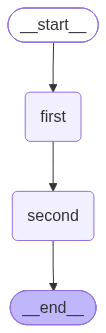

time: 210 ms (started: 2026-09-12 21:42:15 +05:30)


In [11]:
from langgraph.graph import StateGraph, START, END

# The state schema is just a TypedDict. These keys are the whiteboard.
class CounterState(TypedDict):
    question: str
    step_count: int

# A node is an ordinary function: state in, PARTIAL update out.
def first_step(state: CounterState):
    print(f"  first_step sees: {state}")
    return {"step_count": state["step_count"] + 1}      # only the key it changes

def second_step(state: CounterState):
    print(f"  second_step sees: {state}")
    return {"step_count": state["step_count"] + 1}


graph_builder = StateGraph(CounterState)
graph_builder.add_node("first", first_step)
graph_builder.add_node("second", second_step)



graph_builder.add_edge(START, "first")      # START and END are the entry and exit markers
graph_builder.add_edge("first", "second")
graph_builder.add_edge("second", END)
counter_graph = graph_builder.compile()

display(Image(counter_graph.get_graph().draw_mermaid_png()))    # the three edges above, drawn

In [12]:
print("final:", counter_graph.invoke({"question": "anything", "step_count": 0}))

  first_step sees: {'question': 'anything', 'step_count': 0}
  second_step sees: {'question': 'anything', 'step_count': 1}
final: {'question': 'anything', 'step_count': 2}
time: 875 µs (started: 2026-09-12 21:43:52 +05:30)


In [13]:
class NoteState(TypedDict):
    notes: list[str]          # no reducer — the default merge REPLACES this key


def append_first_note(state: NoteState):
    return {"notes": ["note from the first node"]}


def append_second_note(state: NoteState):
    return {"notes": ["note from the second node"]}


builder = StateGraph(NoteState)
builder.add_node("first", append_first_note)
builder.add_node("second", append_second_note)


builder.add_edge(START, "first")
builder.add_edge("first", "second")
builder.add_edge("second", END)

print("result:", builder.compile().invoke({"notes": []}))


result: {'notes': ['note from the second node']}
time: 2.17 ms (started: 2026-09-12 21:46:58 +05:30)


In [14]:
class ReducedNoteState(TypedDict):
    # operator.add concatenates the old list and the returned list instead of replacing.
    notes: Annotated[list[str], operator.add]


builder = StateGraph(ReducedNoteState)
builder.add_node("first", append_first_note)     # the SAME node functions as before
builder.add_node("second", append_second_note)
builder.add_edge(START, "first")
builder.add_edge("first", "second")
builder.add_edge("second", END)

print("result:", builder.compile().invoke({"notes": []}))
print("\n☝️  Both notes survive. Only the state SCHEMA changed — the nodes are untouched.")

result: {'notes': ['note from the first node', 'note from the second node']}

☝️  Both notes survive. Only the state SCHEMA changed — the nodes are untouched.
time: 2.42 ms (started: 2026-09-12 21:47:23 +05:30)


Let's create the `create agent` in Langgraph.

In [15]:
from langchain.messages import ToolMessage

# The agent's instructions from P2, restated so the call_model node below reads on its own.
AGENT_INSTRUCTIONS = (
    "You are InsightAgent, a data analyst for an online-retail store. "
    "Always work in this order: first list the tables, then inspect the schema of every table "
    "you intend to use, and only then write SQL. Never guess a table or column name. "
    "Revenue must EXCLUDE cancelled invoices (invoices.is_cancelled = 1). "
    "State the final answer clearly, including the number."
)


time: 259 µs (started: 2026-09-12 21:50:50 +05:30)


In [18]:
DATABASE_TOOLS

[StructuredTool(name='sql_list_tables', description='List all tables in the retail database.', args_schema=<class 'langchain_core.utils.pydantic.sql_list_tables'>, func=<function sql_list_tables at 0x105c66660>),
 StructuredTool(name='sql_get_schema', description='Show the columns and their types for one table.', args_schema=<class 'langchain_core.utils.pydantic.sql_get_schema'>, func=<function sql_get_schema at 0x1209da980>),
 StructuredTool(name='sql_run', description="Run a read-only SQLite query and return the rows, or a 'SQL ERROR: ...' string.", args_schema=<class 'langchain_core.utils.pydantic.sql_run'>, func=<function sql_run at 0x1209da840>)]

time: 6.51 ms (started: 2026-09-12 21:52:08 +05:30)


In [19]:

from langgraph.graph.message import add_messages


# The state is just the message list, with the add_messages reducer so turns accumulate.
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

# A dictionary from tool name to the tool object, so run_tools can dispatch by name.
TOOLS_BY_NAME = {tool_object.name: tool_object for tool_object in DATABASE_TOOLS}
TOOLS_BY_NAME


{'sql_list_tables': StructuredTool(name='sql_list_tables', description='List all tables in the retail database.', args_schema=<class 'langchain_core.utils.pydantic.sql_list_tables'>, func=<function sql_list_tables at 0x105c66660>),
 'sql_get_schema': StructuredTool(name='sql_get_schema', description='Show the columns and their types for one table.', args_schema=<class 'langchain_core.utils.pydantic.sql_get_schema'>, func=<function sql_get_schema at 0x1209da980>),
 'sql_run': StructuredTool(name='sql_run', description="Run a read-only SQLite query and return the rows, or a 'SQL ERROR: ...' string.", args_schema=<class 'langchain_core.utils.pydantic.sql_run'>, func=<function sql_run at 0x1209da840>)}

time: 1.61 ms (started: 2026-09-12 21:52:38 +05:30)


In [20]:
def call_model(state: AgentState):
    """Node 1 — ask the model what to do next, given the conversation so far."""
    response = model_with_tools.invoke(
        [SystemMessage(AGENT_INSTRUCTIONS)] + state["messages"])
    return {"messages": [response]}      # the reducer appends this

def run_tools(state: AgentState):
    """Node 2 — execute every tool the model asked for, and return the results."""
    tool_messages = []
    for requested_call in state["messages"][-1].tool_calls:
        observation = TOOLS_BY_NAME[requested_call["name"]].invoke(requested_call["args"])
        tool_messages.append(
            ToolMessage(content=str(observation), tool_call_id=requested_call["id"]))
    return {"messages": tool_messages}

def should_continue(state: AgentState) -> Literal["run_tools", "__end__"]:
    """The conditional edge — loop back for tools, or finish."""
    return "run_tools" if state["messages"][-1].tool_calls else END

time: 707 µs (started: 2026-09-12 21:55:50 +05:30)


     __start__ ----> call_model
    call_model ----> __end__
    call_model ----> run_tools
     run_tools ----> call_model


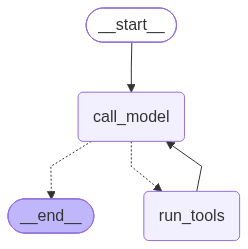

time: 336 ms (started: 2026-09-12 22:02:51 +05:30)


In [21]:
graph_builder = StateGraph(AgentState)
graph_builder.add_node("call_model", call_model)
graph_builder.add_node("run_tools", run_tools)

graph_builder.add_edge(START, "call_model")
graph_builder.add_conditional_edges("call_model", should_continue)
graph_builder.add_edge("run_tools", "call_model")     # the edge that closes the cycle

custom_agent = graph_builder.compile()


def describe_graph(compiled_graph):
    """Print a compiled graph's edges. The graph is an inspectable data structure, not a
    closure — being able to read the shape back out is the whole point of building one."""
    for edge in compiled_graph.get_graph().edges:
        arrow = f"--{edge.data}-->" if edge.data else "---->"
        print(f"  {edge.source:>12s} {arrow} {edge.target}")


describe_graph(custom_agent)

# The same edges, drawn. The two dotted arrows are the conditional edge: after every model call,
# should_continue picks one of them — run_tools, or __end__.
display(Image(custom_agent.get_graph().draw_mermaid_png()))



In [22]:
# The same question P2's prebuilt agent answered, restated so this cell reads on its own.
BUSINESS_QUESTION = "What was our total revenue, excluding cancelled orders?"
graph_result = custom_agent.invoke({"messages": [HumanMessage(BUSINESS_QUESTION)]})
pretty_print("ANSWER:", graph_result["messages"][-1].content)

ANSWER: The total revenue, excluding cancelled orders, is approximately $10,644,560.42.
time: 8.83 s (started: 2026-09-12 22:03:02 +05:30)


In [24]:
for message in graph_result['messages']:
    print(message.content)

What was our total revenue, excluding cancelled orders?

invoices, line_items, products
Table 'invoices': invoice_no (TEXT), customer_id (REAL), invoice_ts (TEXT), country (TEXT), is_cancelled (INTEGER)

SQL ERROR: OperationalError: no such column: line_items.price
It appears that the 'line_items' table does not have a 'price' column. I will inspect the schema of the 'line_items' table to identify the correct column for the item price.
Table 'line_items': invoice_no (TEXT), stock_code (TEXT), quantity (INTEGER), unit_price (REAL)
The 'line_items' table has a 'unit_price' column, which should be used to calculate the revenue. I will now update the SQL query accordingly.
total_revenue
10644560.424
The total revenue, excluding cancelled orders, is approximately $10,644,560.42.
time: 213 µs (started: 2026-09-12 22:04:41 +05:30)


In [25]:
from langgraph.checkpoint.memory import InMemorySaver

# A checkpointer persists state after every step, keyed by thread_id.
checkpointed_agent = graph_builder.compile(checkpointer=InMemorySaver())

thread_config = {"configurable": {"thread_id": "history-demo"}}


checkpointed_agent.invoke({"messages": [HumanMessage("How many invoices are cancelled?")]},
                          thread_config)

# History comes back newest-first; reverse it to read the run forwards.
for snapshot in reversed(list(checkpointed_agent.get_state_history(thread_config))):
    next_node = snapshot.next or ("END",)
    print(f"  {len(snapshot.values['messages'])} messages → next: {next_node}")

  0 messages → next: ('__start__',)
  1 messages → next: ('call_model',)
  2 messages → next: ('run_tools',)
  4 messages → next: ('call_model',)
  5 messages → next: ('run_tools',)
  6 messages → next: ('call_model',)
  7 messages → next: ('END',)
time: 4.56 s (started: 2026-09-12 22:06:24 +05:30)


In [27]:
# The same instructions every agent above was given, restated so this one is readable in place.
AGENT_INSTRUCTIONS = (
    "You are InsightAgent, a data analyst for an online-retail store. "
    "Always work in this order: first list the tables, then inspect the schema of every table "
    "you intend to use, and only then write SQL. Never guess a table or column name. "
    "Revenue must EXCLUDE cancelled invoices (invoices.is_cancelled = 1). "
    "State the final answer clearly, including the number."
)

conversational_agent = create_agent(
    model=f"openai:{WORKER_MODEL}", tools=DATABASE_TOOLS,
    system_prompt=AGENT_INSTRUCTIONS, checkpointer=InMemorySaver())

# Everything sharing this thread_id shares a conversation. A different id is a different one.
session_config = {"configurable": {"thread_id": "analyst-session-1"}}


def ask_in_session(question, config=session_config):
    reply = conversational_agent.invoke({"messages": [HumanMessage(question)]}, config)
    pretty_print(f"Q: {question}\nA: {reply['messages'][-1].content}\n")


ask_in_session("How many invoices are from France?", config=session_config)
ask_in_session("And what fraction of all invoices is that?", config=session_config)   # "that" only resolves via memory

Q: How many invoices are from France?
A: There are 461 invoices from France.

Q: And what fraction of all invoices is that?
A: Total number of invoices: 25,900  
Number of invoices from France: 461

The fraction of invoices from France is \( \frac{461}{25900} \approx 0.0178 \). 

So, approximately 1.78% of all invoices are from France.

time: 8.49 s (started: 2026-09-12 22:08:38 +05:30)


In [29]:
# A different thread_id is a genuinely separate conversation — the pronoun now has no referent.
ask_in_session("What was the first question I asked??", {"configurable": {"thread_id": "analyst-session-1"}})

Q: What was the first question I asked??
A: Your first question was: "How many invoices are from France?"

time: 1.11 s (started: 2026-09-12 22:11:47 +05:30)


In [28]:
# A different thread_id is a genuinely separate conversation — the pronoun now has no referent.
ask_in_session("What was the first question I asked??", {"configurable": {"thread_id": "a-different-session"}})

Q: What was the first question I asked??
A: Your first question was: "What was the first question I asked??"

time: 1.16 s (started: 2026-09-12 22:11:31 +05:30)


#### Reflection

```
  START ─► generate ─► execute ─► judge ──PASS──► END
              ▲                     │
              └────────REVISE───────┘
```

     __start__ ----> generate
       execute ----> judge
      generate ----> execute
         judge ----> __end__
         judge ----> generate


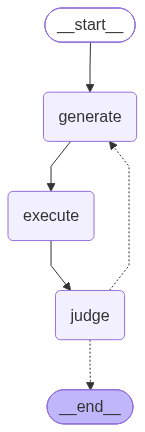

time: 210 ms (started: 2026-09-12 22:26:20 +05:30)


In [34]:
class ReflectionState(TypedDict):
    question: str
    sql: str
    result: str
    verdict: str
    critique: str
    rounds: int

def generate_node(state: ReflectionState):
    """Write a query, using the previous critique as guidance if there was one."""
    schema_text = " ".join(get_schema(t) for t in ["invoices", "products", "line_items"])
    prompt = (f"Schema: {schema_text}\n{state.get('critique', '')}\n\n"
              f"Write ONE SQLite query answering: {state['question']}\nReturn ONLY SQL.")
    raw = language_model.invoke(prompt).content
    fenced = re.search(r"```(?:sql)?\s*(.*?)```", raw, re.S)
    return {"sql": (fenced.group(1) if fenced else raw).strip().rstrip(";"),
            "rounds": state.get("rounds", 0) + 1}

def execute_node(state: ReflectionState):
    """Ground the loop: actually run the query."""
    return {"result": run_sql(state["sql"])}


def judge_node(state: ReflectionState):
    """An independent, stronger model reviews the query against an explicit rule."""
    reviewer = init_chat_model(f"openai:{REVIEWER_MODEL}", temperature=0)
    review = reviewer.invoke(
        f"Question: {state['question']}\nSQL: {state['sql']}\nResult: {state['result']}\n\n"
        "Revenue MUST exclude cancelled invoices (is_cancelled = 1). "
        'Reply as JSON only: {"verdict": "PASS" or "REVISE", "critique": "..."}').content
    parsed = json.loads(re.search(r"\{.*\}", review, re.S).group(0))
    return {"verdict": parsed["verdict"], "critique": parsed["critique"]}


def reflection_router(state: ReflectionState) -> Literal["generate", "__end__"]:
    """Loop back to generate, unless the judge passed it or we have spent 3 rounds."""
    return END if (state["verdict"] == "PASS" or state["rounds"] >= 3) else "generate"


builder = StateGraph(ReflectionState)
builder.add_node("generate", generate_node)
builder.add_node("execute", execute_node)
builder.add_node("judge", judge_node)


builder.add_edge(START, "generate")
builder.add_edge("generate", "execute")
builder.add_edge("execute", "judge")
builder.add_conditional_edges("judge", reflection_router)   # the backwards edge

reflection_graph = builder.compile()

# Note the edge from judge back to generate — a cycle, which a plain pipeline cannot express.
describe_graph(reflection_graph)
display(Image(reflection_graph.get_graph().draw_mermaid_png()))

In [35]:
# The question going into the reflection loop, restated so its SQL can be judged against it.
BUSINESS_QUESTION = "What was our total revenue, excluding cancelled orders?"
reflection_result = reflection_graph.invoke(
    {"question": BUSINESS_QUESTION, "rounds": 0, "critique": ""})
print("verdict:", reflection_result["verdict"], "| rounds used:", reflection_result["rounds"])
pretty_print("final SQL:", reflection_result["sql"])
pretty_print("result:", reflection_result["result"])

verdict: PASS | rounds used: 1
final SQL: SELECT SUM(li.quantity * li.unit_price) AS total_revenue
FROM line_items li
JOIN invoices i ON li.invoice_no = i.invoice_no
WHERE i.is_cancelled = 0
result: total_revenue
10644560.424
time: 2.68 s (started: 2026-09-12 22:27:00 +05:30)


In [39]:
# The question going into the reflection loop, restated so its SQL can be judged against it.
BUSINESS_QUESTION = "What was our total revenue, excluding cancelled orders? and including orders from lakabolo"
reflection_result = reflection_graph.invoke(
    {"question": BUSINESS_QUESTION, "rounds": 0, "critique": ""})
print("verdict:", reflection_result["verdict"], "| rounds used:", reflection_result["rounds"])
pretty_print("final SQL:", reflection_result["sql"])
pretty_print("result:", reflection_result["result"])

verdict: PASS | rounds used: 2
final SQL: SELECT SUM(li.quantity * li.unit_price) AS total_revenue
FROM invoices i
JOIN line_items li ON i.invoice_no = li.invoice_no
WHERE i.is_cancelled = 0
result: total_revenue
10644560.424
time: 5.29 s (started: 2026-09-12 22:28:16 +05:30)


In [41]:
reflection_result

{'question': 'What was our total revenue, excluding cancelled orders? and including orders from lakabolo',
 'sql': 'SELECT SUM(li.quantity * li.unit_price) AS total_revenue\nFROM invoices i\nJOIN line_items li ON i.invoice_no = li.invoice_no\nWHERE i.is_cancelled = 0',
 'result': 'total_revenue\n10644560.424',
 'verdict': 'PASS',
 'critique': 'The query correctly excludes cancelled invoices by filtering on is_cancelled = 0 and includes all orders, including those from lakabolo, as no exclusion is specified. The total revenue calculation is accurate.',
 'rounds': 2}

time: 1.07 ms (started: 2026-09-12 22:28:44 +05:30)


In [44]:
for update_chunk in reflection_graph.stream(
        {"messages": {"question": BUSINESS_QUESTION, "rounds": 0, "critique": ""}},
        stream_mode="updates"):
    # Each chunk is {node_name: the partial update that node returned}.
    for node_name, partial_update in update_chunk.items():
        latest_message = partial_update["messages"][-1]
        if getattr(latest_message, "tool_calls", None):
            print(f"  {node_name:12s} → requests {[c['name'] for c in latest_message.tool_calls]}")
        else:
            print(f"  {node_name:12s} → {str(latest_message.content)[:70]!r}")

KeyError: 'question'

time: 49 ms (started: 2026-09-12 22:31:33 +05:30)


@everyone 

✨ Your IIT-R Experience Is About to Go Beyond the Classroom!

We’re excited to announce the IIT Roorkee Campus Immersion 2026, happening between 13th–15th November 2026. 🎓

For a few days, you’ll get to take your Iearning experience off the screen and onto campus — learning, building, interacting and experiencing the IIT Roorkee ecosystem in person.

Here’s a glimpse of what awaits you:
🏫 Experience IIT Roorkee in person and get a feel for campus life
Interact with IIT Roorkee professors and Scaler faculty
💻 Get hands-on with real-life projects and apply what you’ve been learning
⚡ Take part in exciting hackathons and collaborative challenges
🤝 Meet your fellow learners in person, exchange ideas and build connections
🎓 Be part of an experience that brings together learning and collaboration

And we’re just getting started!

We’re sharing a quick Interest Capture Form to know who would be interested in joining the Campus Immersion. Your response will help us get to know you better and start connecting with you on the experience, activities and everything we have planned.

👉 Interested in experiencing IIT Roorkee beyond the classroom?

Share your interest here:
https://docs.google.com/forms/d/e/1FAIpQLSd5yPquq1J0XYPo1ppGK6OAK6hAK8f1M-HaC9IxTroOligPBg/viewform?usp=sharing&ouid=113200008645481478431
13th–15th November 2026 | IIT Roorkee Campus